In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
#| default_exp generate

In [ ]:
#| export
from tone_datagen.tonegen import RandomToneGen, gamma, uniform, normal, clip, quant
from audiolazy import Streamix, sHz, zeros, ones, line, Stream
from pedalboard import Pedalboard, Reverb
from fastcore.script import call_parse

In [ ]:
from tone_datagen.util import see, hear

In [ ]:
rate = 44100

In [ ]:
tonegen = RandomToneGen(
    gamma(3) * 100 + 20,
    gamma(2) * -2 - 2,
    uniform(0, 0.3) + clip(gamma(0.9) * 0.2, high=4) * 4,
    uniform(0.05, 0.6),
    uniform(),
    uniform(0.05, 1)
)

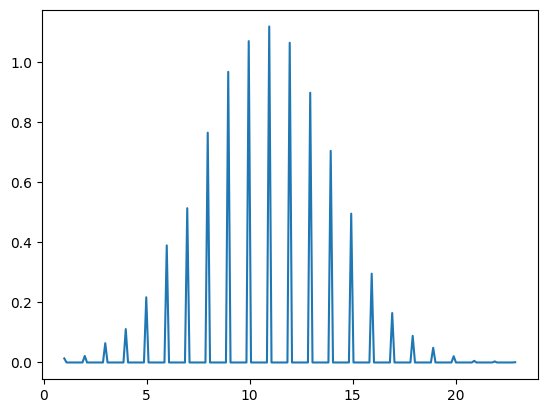

In [ ]:
quant((normal() * 0.8 + 2.7) * 4, range(1, 6 * 4)).pdf()

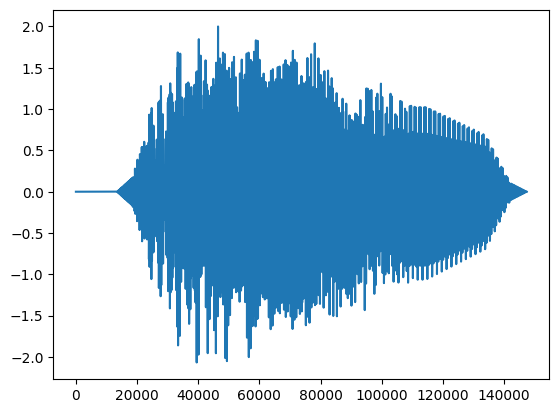

In [ ]:
smix = Streamix()
for _ in range(quant((normal() * 0.8 + 2.7) * 4, range(1, 6 * 4))()):
    smix.add(0, tonegen())
see(smix)
hear(smix)

In [ ]:
reverb = Pedalboard([Reverb(wet_level=1, dry_level=0)])

In [ ]:
#| export
import numpy as np

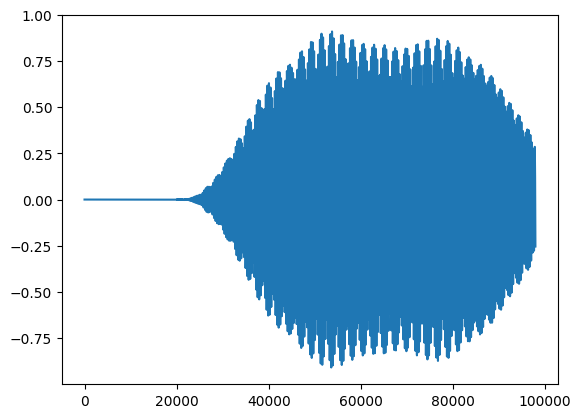

In [ ]:
see(reverb(np.array(list(smix.copy())), rate))

In [ ]:
hear(reverb(np.array(list(smix.copy())), rate))

In [ ]:
s, Hz = sHz(rate)

In [ ]:
smix.append(zeros(s))

<audiolazy.lazy_stream.Streamix>

In [ ]:
hear(reverb(np.array(list(smix.copy())), rate))

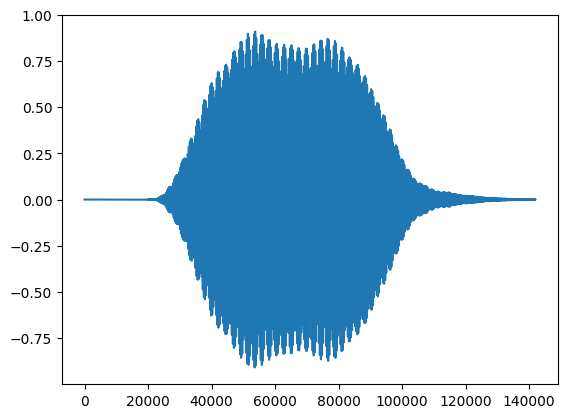

In [ ]:
see(reverb(np.array(list(smix.copy())), rate))

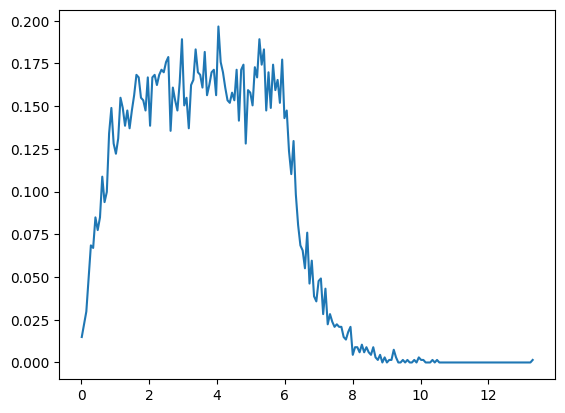

In [ ]:
((uniform(0, 1.5) + clip(gamma(0.9) * 0.2, high=4)) * 4).pdf()

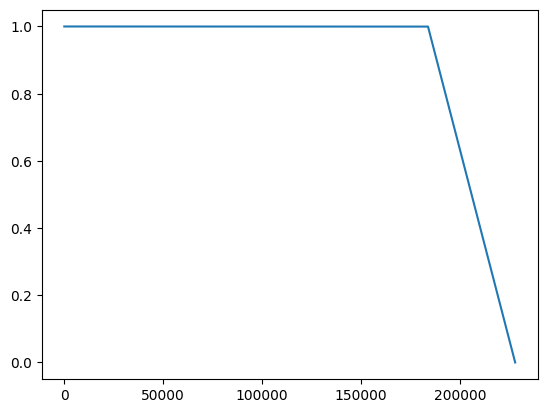

In [ ]:
s, Hz = sHz(rate)
tonegen = RandomToneGen(
    gamma(3) * 100 + 20,
    gamma(2) * -2 - 2,
    (uniform(0, 1.5) + clip(gamma(0.9) * 0.2, high=4)) * 4,
    uniform(0.05, 0.6),
    uniform(),
    uniform(0.05, 1)
)
reverb = Pedalboard([Reverb(wet_level=1, dry_level=0.2, room_size=0.75)])

smix = Streamix()
for _ in range(quant((normal() * 0.8 + 2.7) * 4, range(1, 6 * 4))()):
    smix.add(0, tonegen())

env = Stream(ones(len(list(smix.copy())) + s), line(s, 1, 0))
see(env.copy())

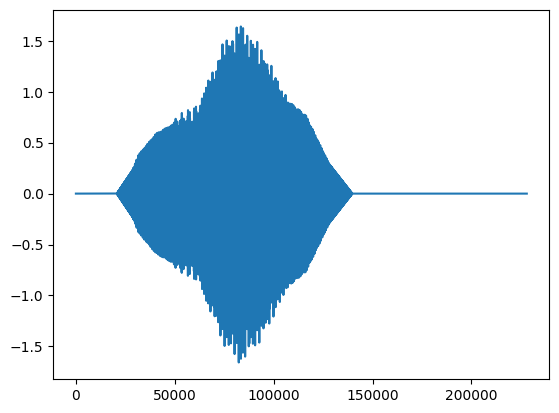

In [ ]:
smix.append(zeros(s * 2))
mix = np.array(list(smix * env.copy()))
see(mix)


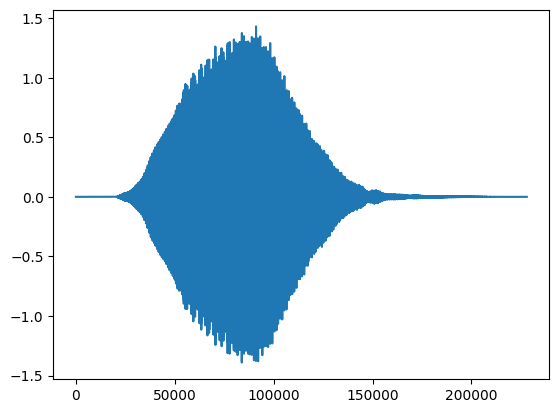

In [ ]:
max_abs = np.max(np.abs(mix))
if max_abs > 1:
    mix /= max_abs

see(np.array(list(env * reverb(mix, rate))))


In [ ]:
#| export
def normalised(stream):
    mix = np.array(list(stream))
    max_abs = np.max(np.abs(mix))
    if max_abs > 1:
        mix /= max_abs

    return mix

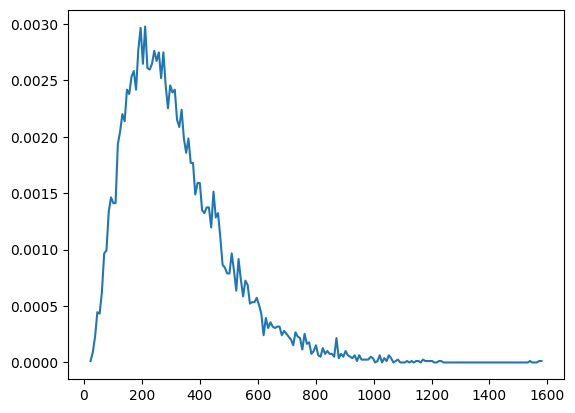

In [ ]:
(gamma(3) * 100 + 20).pdf()

In [ ]:
#| export
def mixed_tones(rate=44100, longerness=1):
    s, Hz = sHz(rate)
    tonegen = RandomToneGen(
        gamma(3) * 100 + 20,
        gamma(2) * -2 - 2,
        (uniform(0, 1.5) + clip(gamma(0.9) * 0.2, high=4)) * longerness,
        uniform(0.05, 0.6),
        uniform() * 1.5,
        uniform(0.05, 1)
    )
    reverb = Pedalboard([Reverb(wet_level=1, dry_level=0.2, room_size=0.75)])
    
    smix = Streamix()
    for _ in range(quant((normal() * 0.8 + 2.7) * longerness, range(1, int(6 * longerness)))()):
        smix.add(0, tonegen())
    env = Stream(ones(len(list(smix.copy())) + s), line(s, 1, 0))
    # make stream as long as envelope
    smix.append(zeros(s * 2))

    mix = normalised(smix)
    return normalised(env * reverb(mix, rate))

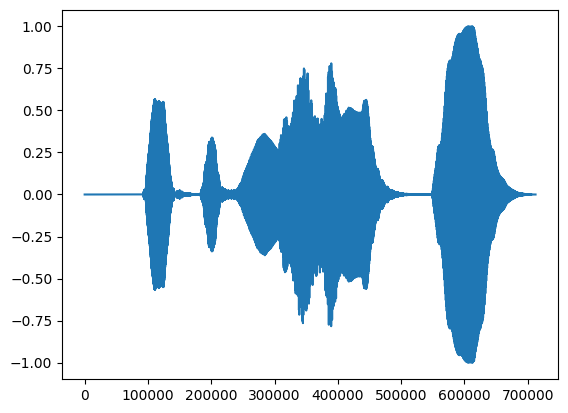

16.155532879818594

In [ ]:
gend = mixed_tones(longerness=6)
see(gend)
hear(gend)
len(gend) / rate

In [ ]:
#| export
def resize_array(arr, desired_length):
    arr = np.asarray(arr)
    current_length = arr.shape[0]
    
    if current_length > desired_length:
        # Truncate
        return arr[:desired_length]
    elif current_length < desired_length:
        # Pad with zeros
        return np.pad(arr, (0, desired_length - current_length), 'constant')
    else:
        # Already the correct length
        return arr

In [ ]:
int(5 * s)

220500

In [ ]:
#| export
from scipy.io.wavfile import write as wavwrite
from pathlib import Path

In [ ]:
2**20

1048576

In [ ]:
        # with closing(wave.open(fname, "wb")) as wf:
        #     wf.setnchannels(1)
        #     wf.setsampwidth(2)
        #     wf.setframerate(rate)
        #     for chunk in chunks((alclip(samp * 2 ** 15, low=-32768, high=32767)).map(int), dfmt="h", padval=0):
        #         wf.writeframes(chunk)

In [ ]:
#| export
@call_parse
def generate(outdir:str=None, n_generate:int=30, longerness:float=1, sample_len:int=2**18, rate:int=44100):
    if outdir is None:
        raise ValueError("outdir must be specified.")
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)
    try:
        fnum = max(int(p.stem) for p in outdir.iterdir() if p.is_file() and p.stem.isdigit())
    except ValueError:
        fnum = -1

    for _ in range(n_generate):
        samp = mixed_tones(longerness=longerness, rate=rate)
        # Has to be a power of two or the model output shape mismatches sample shape
        samp = resize_array(samp, sample_len)

        fnum += 1
        fname = str(outdir / f"{fnum:06d}.wav")

        wavwrite(fname, rate, samp)
        print(f"Wrote {fname}")

In [ ]:
generate("/Users/leoauri/Desktop/phd/inst-train/mixtones")